# 📐 Modelagem Linear para Aprendizado de Máquina

**Prof. Saulo Joel**

---

### 📋 Ementa

> *Construir e interpretar modelos lineares, aplicando-os em problemas reais usando Python e bibliotecas como **scikit-learn** e **TensorFlow**. Estudaremos também técnicas de **regularização** e **seleção de variáveis**, essenciais para a criação de modelos robustos e eficientes.*

### 🎯 Objetivos de Aprendizagem

Ao final desta aula, o aluno será capaz de:

1. **Construir** modelos de regressão linear (simples e múltipla) e regressão logística
2. **Interpretar** os coeficientes e métricas dos modelos lineares
3. **Aplicar técnicas de regularização** (Ridge $L_2$, Lasso $L_1$, ElasticNet) para controlar overfitting
4. **Realizar seleção de variáveis** utilizando Lasso e RFE (Recursive Feature Elimination)
5. **Implementar** modelos lineares tanto com **scikit-learn** quanto com **TensorFlow/Keras**
6. **Avaliar e comparar** modelos usando métricas adequadas e validação cruzada

### 📚 Conteúdo

| Seção | Modelo / Técnica | Tipo | Biblioteca |
|-------|------------------|------|------------|
| 4 | Regressão Linear Simples | Regressão | scikit-learn |
| 5 | Regressão Linear Múltipla | Regressão | scikit-learn |
| 7 | Ridge Regression | Regularização $L_2$ | scikit-learn |
| 8 | Lasso Regression | Regularização $L_1$ | scikit-learn |
| 9 | ElasticNet | Regularização $L_1 + L_2$ | scikit-learn |
| 10 | Seleção de Variáveis | Feature Selection | scikit-learn |
| 11 | Regressão Logística | Classificação | scikit-learn |
| 13 | Regressão Linear com TensorFlow | Regressão | TensorFlow/Keras |

**Datasets utilizados:**
- 🏠 **California Housing** — problema de regressão (prever preço mediano de casas)
- 🌸 **Iris** — problema de classificação (classificar espécies de flores)

## 1. Instalação e Importação das Bibliotecas

Antes de começar, vamos garantir que todas as dependências estejam instaladas no ambiente.

> ⚠️ **Execute a célula abaixo apenas na primeira vez** ou caso alguma biblioteca esteja faltando.

In [68]:
# Instalação das dependências necessárias
%pip install numpy pandas matplotlib seaborn scikit-learn scipy --quiet
%pip install protobuf==5.29.4 --quiet
%pip install tensorflow --quiet

# Correção para conflito protobuf/TensorFlow em ambientes Anaconda
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print("✅ Dependências instaladas!")
print("⚠️  Se for a primeira instalação do TensorFlow, reinicie o kernel antes de continuar.")

Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 5.29.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.52.2 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
✅ Dependências instaladas!
⚠️  Se for a primeira instalação do TensorFlow, reinicie o kernel antes de continuar.


In [69]:
# Correção para conflito protobuf/TensorFlow em ambientes Anaconda
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# Bibliotecas fundamentais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn — Datasets
from sklearn.datasets import fetch_california_housing, load_iris

# Scikit-Learn — Pré-processamento e divisão dos dados
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Scikit-Learn — Modelos Lineares
from sklearn.linear_model import (
    LinearRegression,
    Ridge, RidgeCV,
    Lasso, LassoCV,
    ElasticNet, ElasticNetCV,
    LogisticRegression,
)

# Scikit-Learn — Métricas
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

# Scikit-Learn — Seleção de Variáveis
from sklearn.feature_selection import RFE, SelectFromModel

# TensorFlow / Keras (conforme ementa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas importadas com sucesso!")
print(f"   scikit-learn: {__import__('sklearn').__version__}")
print(f"   TensorFlow:   {tf.__version__}")

✅ Todas as bibliotecas importadas com sucesso!
   scikit-learn: 1.8.0
   TensorFlow:   2.21.0


## 2. Carregamento e Exploração dos Datasets

### 2.1 California Housing (Regressão)
O dataset **California Housing** contém dados do censo da Califórnia de 1990. O objetivo é prever o **valor mediano das casas** (em centenas de milhares de dólares) a partir de características como renda mediana, idade mediana das casas, número de cômodos, etc.

In [70]:
# Carregar o dataset California Housing
california = fetch_california_housing()
df_cal = pd.DataFrame(california.data, columns=california.feature_names)
df_cal['MedHouseVal'] = california.target  # variável-alvo

print("📊 California Housing Dataset")
print(f"   Amostras: {df_cal.shape[0]} | Features: {df_cal.shape[1] - 1}")
print(f"   Variável-alvo: MedHouseVal (valor mediano da casa em $100k)\n")
print("Primeiras linhas:")
df_cal.head()

📊 California Housing Dataset
   Amostras: 20640 | Features: 8
   Variável-alvo: MedHouseVal (valor mediano da casa em $100k)

Primeiras linhas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [71]:
# Informações e estatísticas descritivas
print("Informações do dataset:")
print(df_cal.info())
print("\n" + "="*60)
print("\nEstatísticas descritivas:")
df_cal.describe()

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


Estatísticas descritivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


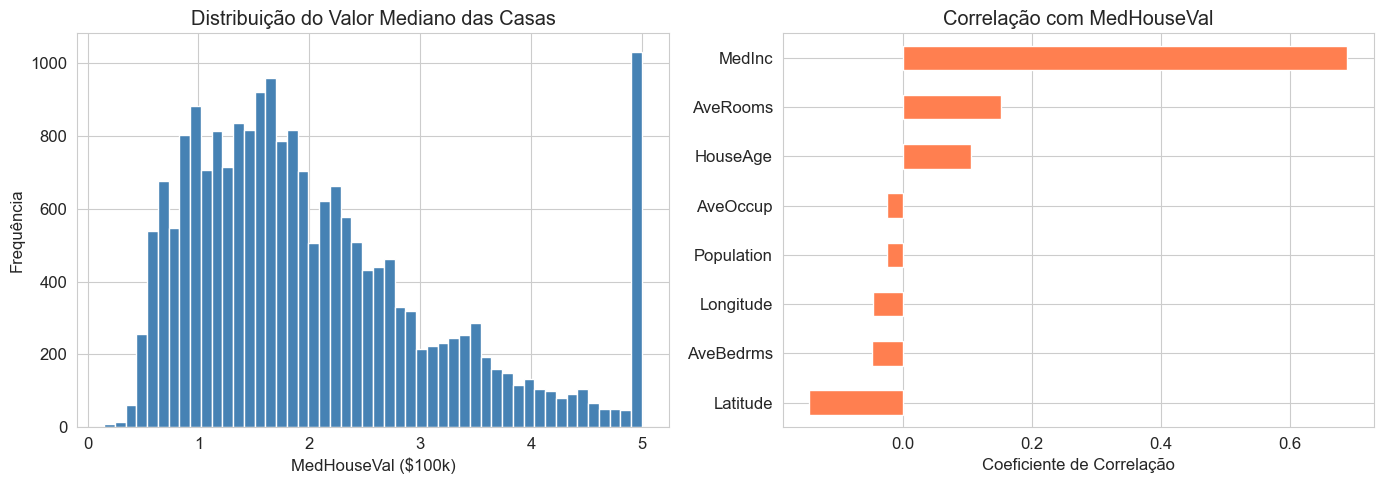

In [72]:
# Distribuição da variável-alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_cal['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Valor Mediano das Casas')
axes[0].set_xlabel('MedHouseVal ($100k)')
axes[0].set_ylabel('Frequência')

# Correlação entre features e a variável-alvo
corr = df_cal.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
corr.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Correlação com MedHouseVal')
axes[1].set_xlabel('Coeficiente de Correlação')

plt.tight_layout()
plt.show()

### 2.2 Iris (Classificação)
O dataset **Iris** é um dos mais clássicos da área de ML. Contém medidas de 150 flores de 3 espécies (*setosa*, *versicolor*, *virginica*), com 4 features cada.

In [73]:
# Carregar o dataset Iris
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df_iris['target'] = iris.target

print("🌸 Iris Dataset")
print(f"   Amostras: {df_iris.shape[0]} | Features: 4")
print(f"   Classes: {list(iris.target_names)}\n")

print("Distribuição das classes:")
print(df_iris['species'].value_counts())
print()
df_iris.head()

🌸 Iris Dataset
   Amostras: 150 | Features: 4
   Classes: ['setosa', 'versicolor', 'virginica']

Distribuição das classes:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


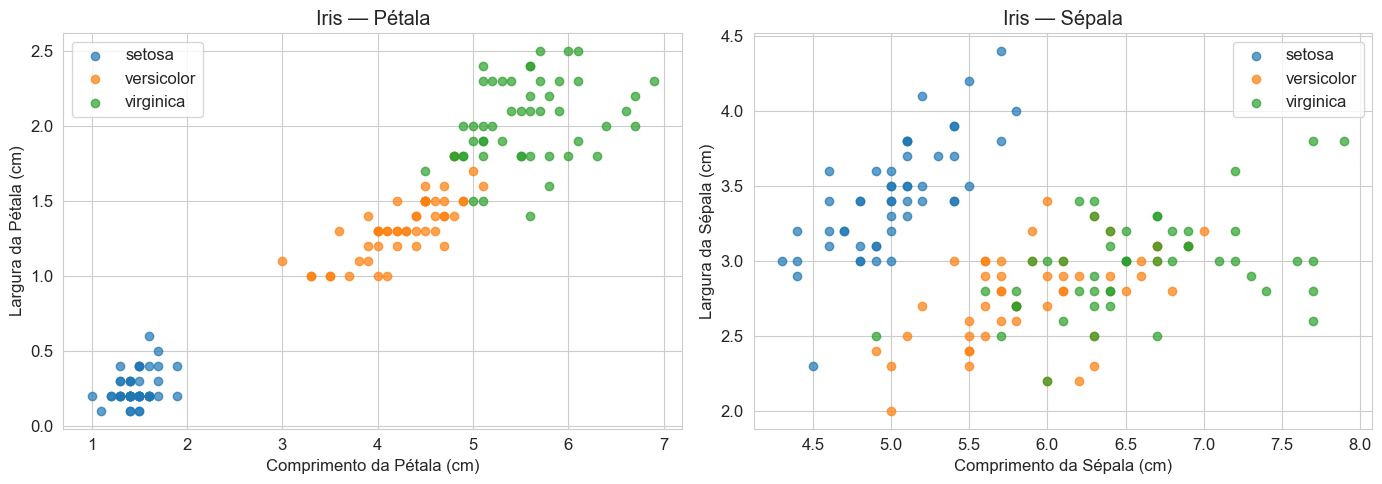

In [74]:
# Visualização do dataset Iris
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pairplot simplificado: duas features principais
for species in iris.target_names:
    subset = df_iris[df_iris['species'] == species]
    axes[0].scatter(subset['petal length (cm)'], subset['petal width (cm)'], label=species, alpha=0.7)
axes[0].set_xlabel('Comprimento da Pétala (cm)')
axes[0].set_ylabel('Largura da Pétala (cm)')
axes[0].set_title('Iris — Pétala')
axes[0].legend()

for species in iris.target_names:
    subset = df_iris[df_iris['species'] == species]
    axes[1].scatter(subset['sepal length (cm)'], subset['sepal width (cm)'], label=species, alpha=0.7)
axes[1].set_xlabel('Comprimento da Sépala (cm)')
axes[1].set_ylabel('Largura da Sépala (cm)')
axes[1].set_title('Iris — Sépala')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Pré-processamento dos Dados e Divisão Treino/Teste

Antes de treinar os modelos, precisamos:

1. **Normalizar as features** com `StandardScaler` — transforma cada feature para ter média 0 e desvio padrão 1:

$$z = \frac{x - \mu}{\sigma}$$

2. **Dividir os dados** em treino (80%) e teste (20%) com `train_test_split`.

In [75]:
RANDOM_STATE = 42

# ============================================================
# California Housing — Regressão
# ============================================================
X_cal = df_cal.drop('MedHouseVal', axis=1)
y_cal = df_cal['MedHouseVal']

# Dividir em treino e teste
X_cal_train, X_cal_test, y_cal_train, y_cal_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=RANDOM_STATE
)

# Normalizar as features
scaler_cal = StandardScaler()
X_cal_train_scaled = scaler_cal.fit_transform(X_cal_train)
X_cal_test_scaled = scaler_cal.transform(X_cal_test)

print("🏠 California Housing:")
print(f"   Treino: {X_cal_train_scaled.shape[0]} amostras")
print(f"   Teste:  {X_cal_test_scaled.shape[0]} amostras")

# ============================================================
# Iris — Classificação
# ============================================================
X_iris = df_iris[iris.feature_names]
y_iris = df_iris['target']

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=RANDOM_STATE, stratify=y_iris
)

scaler_iris = StandardScaler()
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_iris.transform(X_iris_test)

print(f"\n🌸 Iris:")
print(f"   Treino: {X_iris_train_scaled.shape[0]} amostras")
print(f"   Teste:  {X_iris_test_scaled.shape[0]} amostras")

🏠 California Housing:
   Treino: 16512 amostras
   Teste:  4128 amostras

🌸 Iris:
   Treino: 120 amostras
   Teste:  30 amostras


## 4. Regressão Linear Simples

A regressão linear simples modela a relação entre **uma feature** ($x$) e a **variável-alvo** ($y$):

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x$$

Onde:
- $\hat{\beta}_0$ é o **intercepto** (valor de $\hat{y}$ quando $x = 0$)
- $\hat{\beta}_1$ é a **inclinação** (variação em $\hat{y}$ para cada unidade de variação em $x$)

Os coeficientes são estimados minimizando a **soma dos quadrados dos resíduos (OLS)**:

$$\min_{\beta_0, \beta_1} \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2$$

Vamos usar a feature **MedInc** (renda mediana) que possui a maior correlação com o preço.

  REGRESSÃO LINEAR SIMPLES
  Intercepto (β₀): 0.4446
  Inclinação (β₁): 0.4193

  Equação: ŷ = 0.4446 + 0.4193 × MedInc


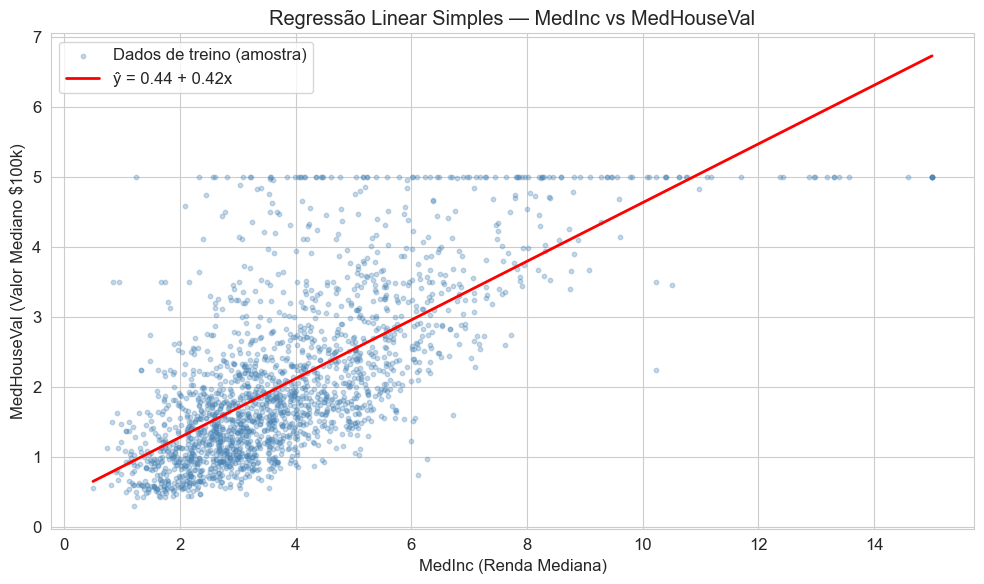


📊 R² no teste: 0.4589
   MSE no teste: 0.7091


In [76]:
# Regressão Linear Simples: usar apenas a feature MedInc
X_simple_train = X_cal_train[['MedInc']].values
X_simple_test = X_cal_test[['MedInc']].values

# Treinar o modelo
lr_simple = LinearRegression()
lr_simple.fit(X_simple_train, y_cal_train)

# Coeficientes
beta_0 = lr_simple.intercept_
beta_1 = lr_simple.coef_[0]

print("=" * 50)
print("  REGRESSÃO LINEAR SIMPLES")
print("=" * 50)
print(f"  Intercepto (β₀): {beta_0:.4f}")
print(f"  Inclinação (β₁): {beta_1:.4f}")
print(f"\n  Equação: ŷ = {beta_0:.4f} + {beta_1:.4f} × MedInc")
print("=" * 50)

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))

# Amostra para não sobrecarregar o gráfico
sample_idx = np.random.RandomState(42).choice(len(X_simple_train), size=2000, replace=False)
ax.scatter(X_simple_train[sample_idx], y_cal_train.iloc[sample_idx],
           alpha=0.3, s=10, color='steelblue', label='Dados de treino (amostra)')

# Reta de regressão
x_line = np.linspace(X_simple_train.min(), X_simple_train.max(), 100)
y_line = beta_0 + beta_1 * x_line
ax.plot(x_line, y_line, color='red', linewidth=2, label=f'ŷ = {beta_0:.2f} + {beta_1:.2f}x')

ax.set_xlabel('MedInc (Renda Mediana)')
ax.set_ylabel('MedHouseVal (Valor Mediano $100k)')
ax.set_title('Regressão Linear Simples — MedInc vs MedHouseVal')
ax.legend()
plt.tight_layout()
plt.show()

# Métricas
y_pred_simple = lr_simple.predict(X_simple_test)
print(f"\n📊 R² no teste: {r2_score(y_cal_test, y_pred_simple):.4f}")
print(f"   MSE no teste: {mean_squared_error(y_cal_test, y_pred_simple):.4f}")

## 5. Regressão Linear Múltipla

Agora usamos **todas as features** para prever o valor da casa:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Ou em notação matricial:

$$\hat{y} = X\boldsymbol{\beta}$$

Onde $\boldsymbol{\beta} = (X^T X)^{-1} X^T y$ é a **solução OLS (Ordinary Least Squares)**.

  REGRESSÃO LINEAR MÚLTIPLA — Coeficientes
  Feature          Coeficiente
------------------------------
  Latitude             -0.8969
  Longitude            -0.8698
  MedInc                0.8544
  AveBedrms             0.3393
  AveRooms             -0.2944
  HouseAge              0.1225
  AveOccup             -0.0408
  Population           -0.0023
------------------------------
  Intercepto            2.0719


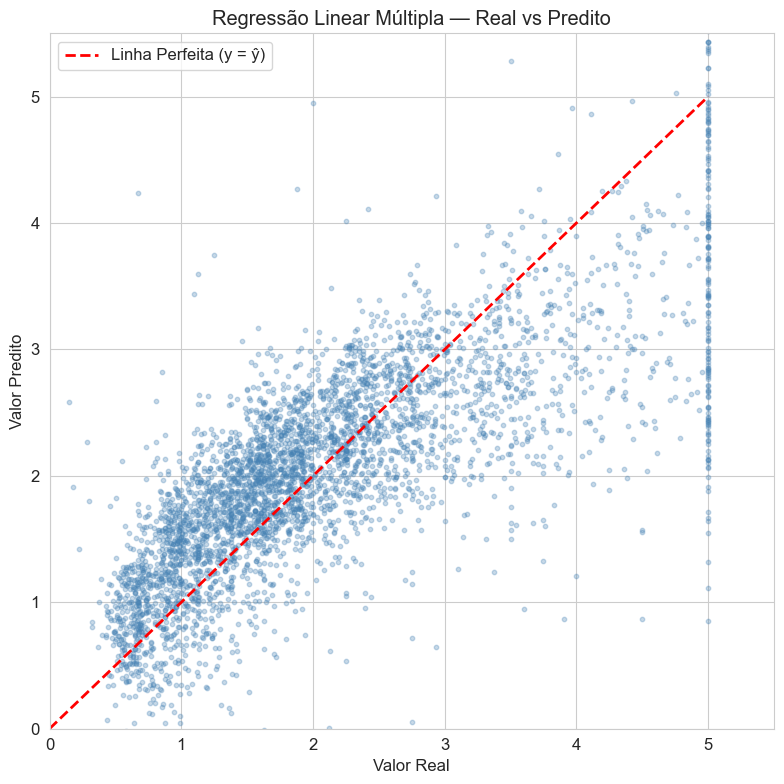

In [77]:
# Regressão Linear Múltipla (todas as features, dados normalizados)
lr_multi = LinearRegression()
lr_multi.fit(X_cal_train_scaled, y_cal_train)
y_pred_multi = lr_multi.predict(X_cal_test_scaled)

# Coeficientes do modelo
print("=" * 60)
print("  REGRESSÃO LINEAR MÚLTIPLA — Coeficientes")
print("=" * 60)
print(f"  {'Feature':<15} {'Coeficiente':>12}")
print("-" * 30)
for feat, coef in sorted(zip(california.feature_names, lr_multi.coef_),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<15} {coef:>12.4f}")
print("-" * 30)
print(f"  {'Intercepto':<15} {lr_multi.intercept_:>12.4f}")
print("=" * 60)

# Gráfico: Predito vs Real
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_cal_test, y_pred_multi, alpha=0.3, s=10, color='steelblue')
ax.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Linha Perfeita (y = ŷ)')
ax.set_xlabel('Valor Real')
ax.set_ylabel('Valor Predito')
ax.set_title('Regressão Linear Múltipla — Real vs Predito')
ax.legend()
ax.set_xlim(0, 5.5)
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

## 6. Avaliação de Métricas da Regressão

As métricas fundamentais para avaliação de modelos de regressão:

| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **R²** | $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proporção da variância explicada (0 a 1) |
| **MSE** | $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | Erro quadrático médio |
| **RMSE** | $RMSE = \sqrt{MSE}$ | Raiz do MSE (mesma unidade de $y$) |
| **MAE** | $MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$ | Erro absoluto médio |

  MÉTRICAS — Regressão Linear Múltipla
  R² (coef. de determinação): 0.5758
  MSE (erro quadrático médio): 0.5559
  RMSE (raiz do MSE):          0.7456
  MAE (erro absoluto médio):    0.5332


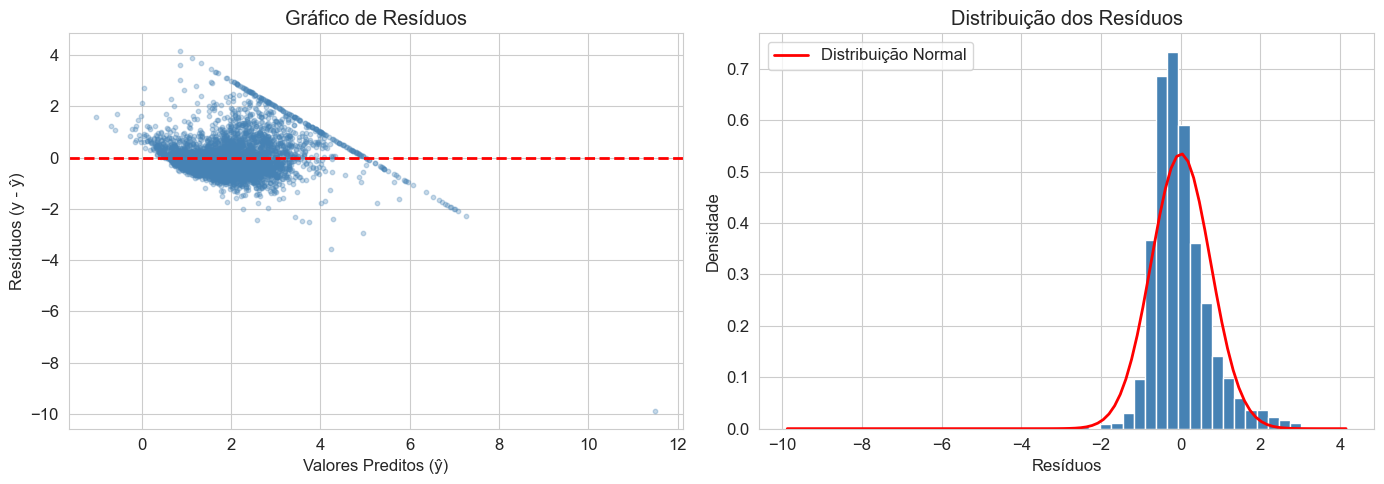

In [78]:
# Métricas da Regressão Linear Múltipla
r2 = r2_score(y_cal_test, y_pred_multi)
mse = mean_squared_error(y_cal_test, y_pred_multi)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_cal_test, y_pred_multi)

print("=" * 50)
print("  MÉTRICAS — Regressão Linear Múltipla")
print("=" * 50)
print(f"  R² (coef. de determinação): {r2:.4f}")
print(f"  MSE (erro quadrático médio): {mse:.4f}")
print(f"  RMSE (raiz do MSE):          {rmse:.4f}")
print(f"  MAE (erro absoluto médio):    {mae:.4f}")
print("=" * 50)

# Gráfico de Resíduos
residuos = y_cal_test - y_pred_multi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Valores preditos
axes[0].scatter(y_pred_multi, residuos, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Preditos (ŷ)')
axes[0].set_ylabel('Resíduos (y - ŷ)')
axes[0].set_title('Gráfico de Resíduos')

# Distribuição dos resíduos
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='white', density=True)
axes[1].set_xlabel('Resíduos')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Distribuição dos Resíduos')

# Curva normal para referência
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
from scipy.stats import norm
axes[1].plot(x_norm, norm.pdf(x_norm, residuos.mean(), residuos.std()),
             'r-', linewidth=2, label='Distribuição Normal')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Regularização com Ridge Regression ($L_2$)

O Ridge adiciona uma **penalidade $L_2$** (norma quadrática) sobre os coeficientes à função custo:

$$J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

**Efeito:** Os coeficientes são **encolhidos** (shrinkage) em direção a zero, mas **nunca são zerados**. Isso reduz o overfitting ao controlar a magnitude dos coeficientes.

O parâmetro $\alpha$ controla a intensidade da regularização:
- $\alpha = 0$: equivale à regressão linear comum
- $\alpha \to \infty$: todos os coeficientes tendem a zero

  RIDGE REGRESSION (L₂)
  Melhor α: 0.0010
  R²: 0.5758
  MSE: 0.5559
  MAE: 0.5332


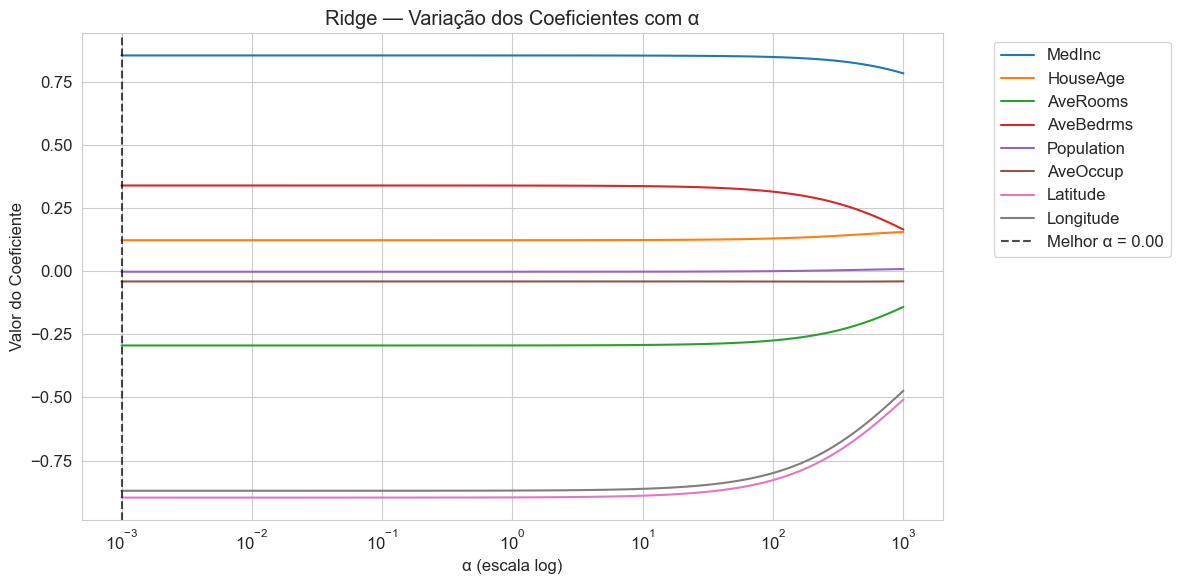

In [79]:
# Ridge Regression com validação cruzada para encontrar o melhor alpha
alphas_ridge = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_cv.fit(X_cal_train_scaled, y_cal_train)
y_pred_ridge = ridge_cv.predict(X_cal_test_scaled)

print("=" * 50)
print("  RIDGE REGRESSION (L₂)")
print("=" * 50)
print(f"  Melhor α: {ridge_cv.alpha_:.4f}")
print(f"  R²: {r2_score(y_cal_test, y_pred_ridge):.4f}")
print(f"  MSE: {mean_squared_error(y_cal_test, y_pred_ridge):.4f}")
print(f"  MAE: {mean_absolute_error(y_cal_test, y_pred_ridge):.4f}")
print("=" * 50)

# Como os coeficientes variam com alpha
fig, ax = plt.subplots(figsize=(12, 6))

coefs_ridge = []
for a in alphas_ridge:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_cal_train_scaled, y_cal_train)
    coefs_ridge.append(ridge_temp.coef_)

coefs_ridge = np.array(coefs_ridge)

for i, feat in enumerate(california.feature_names):
    ax.plot(alphas_ridge, coefs_ridge[:, i], label=feat)

ax.axvline(x=ridge_cv.alpha_, color='black', linestyle='--', alpha=0.7, label=f'Melhor α = {ridge_cv.alpha_:.2f}')
ax.set_xscale('log')
ax.set_xlabel('α (escala log)')
ax.set_ylabel('Valor do Coeficiente')
ax.set_title('Ridge — Variação dos Coeficientes com α')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Regularização com Lasso Regression ($L_1$)

O Lasso utiliza uma **penalidade $L_1$** (norma absoluta):

$$J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

**Vantagem principal:** O Lasso pode zerar coeficientes completamente, realizando **seleção automática de features**. Isso o torna ideal quando suspeitamos que apenas um subconjunto das features é relevante.

  LASSO REGRESSION (L₁)
  Melhor α: 0.000643
  R²: 0.5765
  MSE: 0.5550
  MAE: 0.5332

📋 Coeficientes do Lasso:
  Feature          Coeficiente     Status
----------------------------------------
  MedInc                0.8510    ✅ Ativa
  HouseAge              0.1231    ✅ Ativa
  AveRooms             -0.2860    ✅ Ativa
  AveBedrms             0.3308    ✅ Ativa
  Population           -0.0015    ✅ Ativa
  AveOccup             -0.0402    ✅ Ativa
  Latitude             -0.8898    ✅ Ativa
  Longitude            -0.8623    ✅ Ativa

  Features zeradas: 0/8


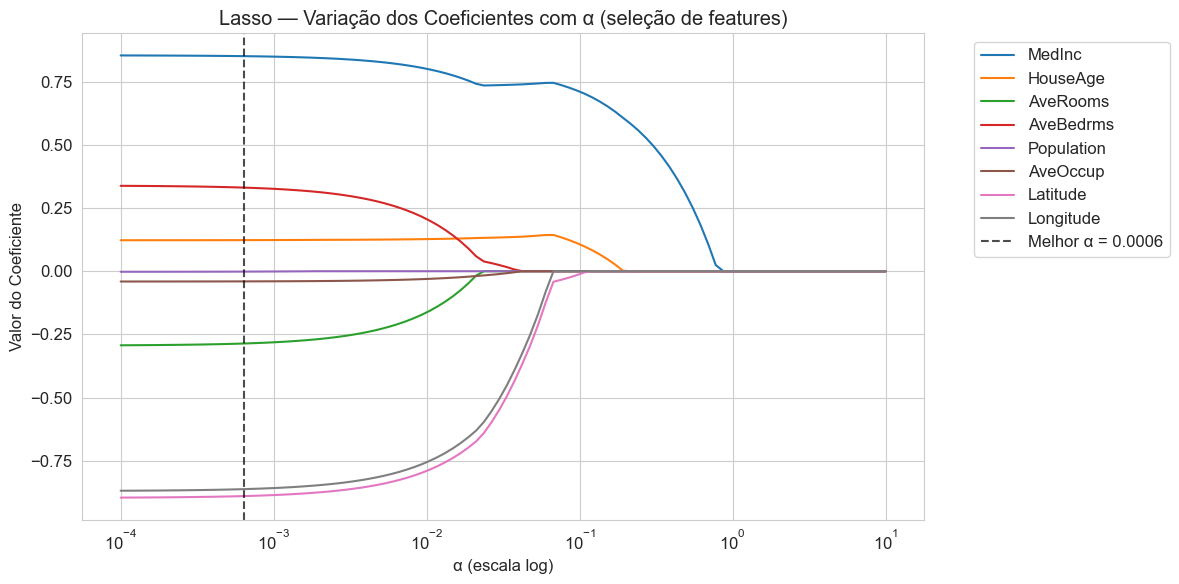

In [80]:
# Lasso Regression com validação cruzada
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_cal_train_scaled, y_cal_train)
y_pred_lasso = lasso_cv.predict(X_cal_test_scaled)

print("=" * 50)
print("  LASSO REGRESSION (L₁)")
print("=" * 50)
print(f"  Melhor α: {lasso_cv.alpha_:.6f}")
print(f"  R²: {r2_score(y_cal_test, y_pred_lasso):.4f}")
print(f"  MSE: {mean_squared_error(y_cal_test, y_pred_lasso):.4f}")
print(f"  MAE: {mean_absolute_error(y_cal_test, y_pred_lasso):.4f}")
print("=" * 50)

# Coeficientes e seleção de features
print("\n📋 Coeficientes do Lasso:")
print(f"  {'Feature':<15} {'Coeficiente':>12} {'Status':>10}")
print("-" * 40)
for feat, coef in zip(california.feature_names, lasso_cv.coef_):
    status = "✅ Ativa" if abs(coef) > 1e-6 else "❌ Zerada"
    print(f"  {feat:<15} {coef:>12.4f} {status:>10}")

n_zerados = np.sum(np.abs(lasso_cv.coef_) < 1e-6)
print(f"\n  Features zeradas: {n_zerados}/{len(california.feature_names)}")

# Gráfico da variação dos coeficientes com alpha
fig, ax = plt.subplots(figsize=(12, 6))

alphas_lasso = np.logspace(-4, 1, 100)
coefs_lasso = []
for a in alphas_lasso:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_cal_train_scaled, y_cal_train)
    coefs_lasso.append(lasso_temp.coef_)

coefs_lasso = np.array(coefs_lasso)

for i, feat in enumerate(california.feature_names):
    ax.plot(alphas_lasso, coefs_lasso[:, i], label=feat)

ax.axvline(x=lasso_cv.alpha_, color='black', linestyle='--', alpha=0.7,
           label=f'Melhor α = {lasso_cv.alpha_:.4f}')
ax.set_xscale('log')
ax.set_xlabel('α (escala log)')
ax.set_ylabel('Valor do Coeficiente')
ax.set_title('Lasso — Variação dos Coeficientes com α (seleção de features)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Comparação com ElasticNet ($L_1 + L_2$)

O **ElasticNet** combina as penalidades Ridge e Lasso:

$$J(\boldsymbol{\beta}) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \left( \rho \sum_{j=1}^{p}|\beta_j| + \frac{1-\rho}{2} \sum_{j=1}^{p}\beta_j^2 \right)$$

Onde:
- $\alpha$ controla a intensidade geral da regularização
- $\rho$ (`l1_ratio`) controla a mistura entre $L_1$ e $L_2$:
  - $\rho = 1$: puro Lasso
  - $\rho = 0$: puro Ridge
  - $0 < \rho < 1$: combinação de ambos

In [81]:
# ElasticNet com validação cruzada
enet_cv = ElasticNetCV(
    alphas=np.logspace(-4, 1, 50),
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    cv=5, random_state=RANDOM_STATE, max_iter=10000
)
enet_cv.fit(X_cal_train_scaled, y_cal_train)
y_pred_enet = enet_cv.predict(X_cal_test_scaled)

print("=" * 50)
print("  ELASTICNET (L₁ + L₂)")
print("=" * 50)
print(f"  Melhor α:        {enet_cv.alpha_:.6f}")
print(f"  Melhor l1_ratio: {enet_cv.l1_ratio_:.2f}")
print(f"  R²: {r2_score(y_cal_test, y_pred_enet):.4f}")
print(f"  MSE: {mean_squared_error(y_cal_test, y_pred_enet):.4f}")
print(f"  MAE: {mean_absolute_error(y_cal_test, y_pred_enet):.4f}")
print("=" * 50)

# ============================================================
# Tabela comparativa dos 3 modelos regularizados + Linear
# ============================================================
models_reg = {
    'Linear': (lr_multi, y_pred_multi),
    'Ridge': (ridge_cv, y_pred_ridge),
    'Lasso': (lasso_cv, y_pred_lasso),
    'ElasticNet': (enet_cv, y_pred_enet),
}

resultados = []
for nome, (modelo, y_pred) in models_reg.items():
    resultados.append({
        'Modelo': nome,
        'R²': r2_score(y_cal_test, y_pred),
        'MSE': mean_squared_error(y_cal_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_cal_test, y_pred)),
        'MAE': mean_absolute_error(y_cal_test, y_pred),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print("\n📊 Comparação de Métricas:")
df_resultados.style.format('{:.4f}').highlight_min(axis=0, subset=['MSE', 'RMSE', 'MAE']).highlight_max(axis=0, subset=['R²'])

  ELASTICNET (L₁ + L₂)
  Melhor α:        0.000655
  Melhor l1_ratio: 0.95
  R²: 0.5765
  MSE: 0.5550
  MAE: 0.5332

📊 Comparação de Métricas:


,R²,MSE,RMSE,MAE
Modelo,,,,
Linear,0.5758,0.5559,0.7456,0.5332
Ridge,0.5758,0.5559,0.7456,0.5332
Lasso,0.5765,0.5550,0.7450,0.5332
ElasticNet,0.5765,0.5550,0.7450,0.5332


## 10. Seleção de Variáveis

A **seleção de variáveis** (feature selection) é fundamental para construir modelos **robustos e eficientes**. Modelos com variáveis irrelevantes tendem a sofrer de overfitting e são mais difíceis de interpretar.

### Técnicas abordadas:

| Técnica | Estratégia | Como funciona |
|---------|-----------|---------------|
| **Lasso** (embutida) | Regularização $L_1$ | Zera coeficientes de features irrelevantes |
| **RFE** (wrapper) | Eliminação Recursiva | Remove features menos importantes iterativamente |
| **SelectFromModel** (embutida) | Baseada em importância | Seleciona features com coeficientes acima de um limiar |

> 💡 **Nota:** A seleção de variáveis reduz a dimensionalidade, melhora a interpretabilidade e pode aumentar a generalização do modelo.

In [82]:
# ============================================================
# 10.1 Seleção via Lasso (já treinado)
# ============================================================
print("=" * 60)
print("  SELEÇÃO DE VARIÁVEIS")
print("=" * 60)

# Features selecionadas pelo Lasso
print("\n📌 10.1 — Seleção via Lasso (coeficientes ≠ 0):")
lasso_features = pd.DataFrame({
    'Feature': california.feature_names,
    'Coef. Lasso': lasso_cv.coef_,
    'Selecionada': np.abs(lasso_cv.coef_) > 1e-6
})
lasso_features['|Coef.|'] = np.abs(lasso_features['Coef. Lasso'])
lasso_features = lasso_features.sort_values('|Coef.|', ascending=False)
print(lasso_features[['Feature', 'Coef. Lasso', 'Selecionada']].to_string(index=False))

# ============================================================
# 10.2 RFE — Recursive Feature Elimination
# ============================================================
print("\n📌 10.2 — RFE (Recursive Feature Elimination):")
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5, step=1)
rfe.fit(X_cal_train_scaled, y_cal_train)

rfe_results = pd.DataFrame({
    'Feature': california.feature_names,
    'Ranking': rfe.ranking_,
    'Selecionada': rfe.support_
}).sort_values('Ranking')
print(rfe_results.to_string(index=False))

# Score com features selecionadas por RFE
y_pred_rfe = rfe.predict(X_cal_test_scaled)
print(f"\n  R² com RFE (5 features): {r2_score(y_cal_test, y_pred_rfe):.4f}")
print(f"  R² com todas features:   {r2_score(y_cal_test, y_pred_multi):.4f}")

# ============================================================
# 10.3 SelectFromModel (com Lasso como estimador)
# ============================================================
print("\n📌 10.3 — SelectFromModel (baseado no Lasso):")
sfm = SelectFromModel(lasso_cv, prefit=True)
X_cal_train_sfm = sfm.transform(X_cal_train_scaled)
X_cal_test_sfm = sfm.transform(X_cal_test_scaled)

selected_mask = sfm.get_support()
selected_features = [f for f, s in zip(california.feature_names, selected_mask) if s]
print(f"  Features selecionadas ({len(selected_features)}): {selected_features}")

lr_sfm = LinearRegression().fit(X_cal_train_sfm, y_cal_train)
y_pred_sfm = lr_sfm.predict(X_cal_test_sfm)
print(f"  R² com SelectFromModel: {r2_score(y_cal_test, y_pred_sfm):.4f}")

  SELEÇÃO DE VARIÁVEIS

📌 10.1 — Seleção via Lasso (coeficientes ≠ 0):
   Feature  Coef. Lasso  Selecionada
  Latitude    -0.889769         True
 Longitude    -0.862271         True
    MedInc     0.851022         True
 AveBedrms     0.330780         True
  AveRooms    -0.285981         True
  HouseAge     0.123062         True
  AveOccup    -0.040226         True
Population    -0.001506         True

📌 10.2 — RFE (Recursive Feature Elimination):
   Feature  Ranking  Selecionada
    MedInc        1         True
  AveRooms        1         True
 AveBedrms        1         True
  Latitude        1         True
 Longitude        1         True
  HouseAge        2        False
  AveOccup        3        False
Population        4        False

  R² com RFE (5 features): 0.5675
  R² com todas features:   0.5758

📌 10.3 — SelectFromModel (baseado no Lasso):
  Features selecionadas (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  R² com 

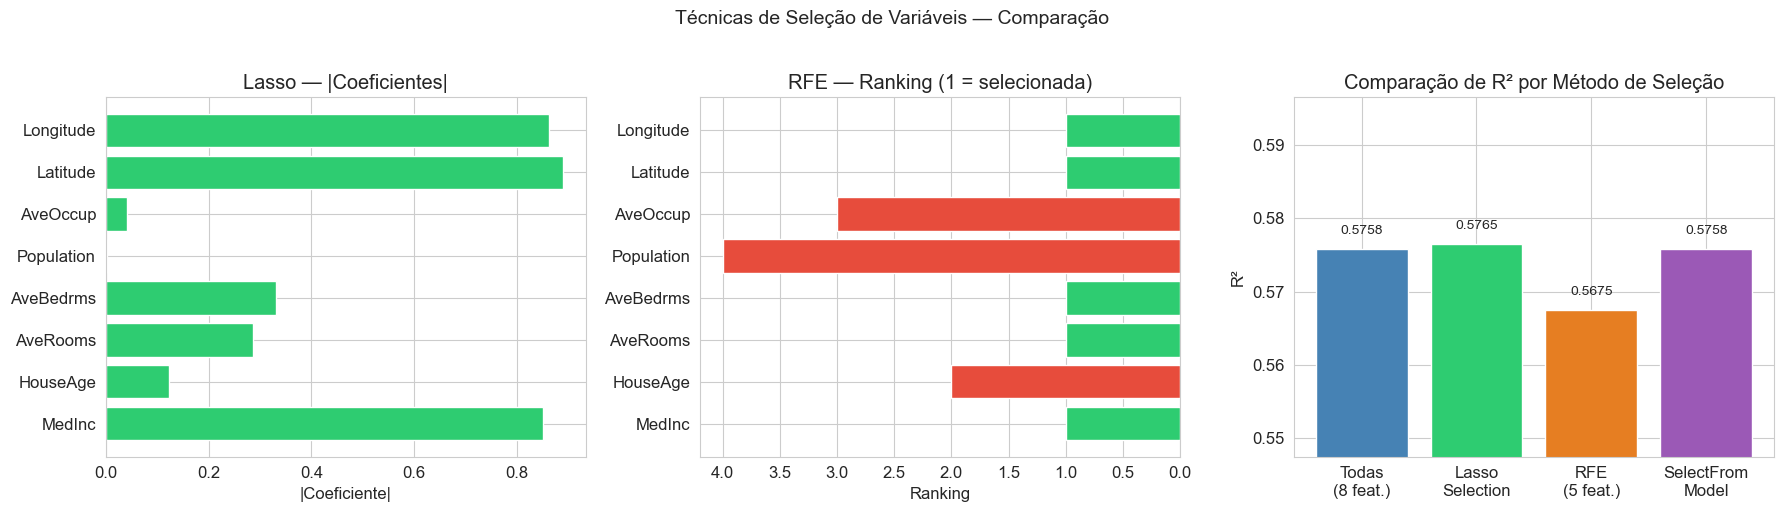

In [83]:
# Visualização comparativa das técnicas de seleção
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lasso
colors_lasso = ['#2ecc71' if abs(c) > 1e-6 else '#e74c3c' for c in lasso_cv.coef_]
axes[0].barh(california.feature_names, np.abs(lasso_cv.coef_), color=colors_lasso)
axes[0].set_title('Lasso — |Coeficientes|')
axes[0].set_xlabel('|Coeficiente|')

# RFE ranking
colors_rfe = ['#2ecc71' if r == 1 else '#e74c3c' for r in rfe.ranking_]
axes[1].barh(california.feature_names, rfe.ranking_, color=colors_rfe)
axes[1].set_title('RFE — Ranking (1 = selecionada)')
axes[1].set_xlabel('Ranking')
axes[1].invert_xaxis()

# Resumo comparativo
methods = ['Todas\n(8 feat.)', 'Lasso\nSelection', 'RFE\n(5 feat.)', 'SelectFrom\nModel']
r2_scores = [
    r2_score(y_cal_test, y_pred_multi),
    r2_score(y_cal_test, y_pred_lasso),
    r2_score(y_cal_test, y_pred_rfe),
    r2_score(y_cal_test, y_pred_sfm),
]
bars = axes[2].bar(methods, r2_scores, color=['steelblue', '#2ecc71', '#e67e22', '#9b59b6'])
axes[2].set_ylabel('R²')
axes[2].set_title('Comparação de R² por Método de Seleção')
axes[2].set_ylim(min(r2_scores) - 0.02, max(r2_scores) + 0.02)
for bar, score in zip(bars, r2_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{score:.4f}', ha='center', fontsize=10)

plt.suptitle('Técnicas de Seleção de Variáveis — Comparação', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Regressão Logística para Classificação (Dataset Iris)

A **Regressão Logística** é um modelo linear para **classificação**. Apesar do nome, não é usada para regressão!

### Caso binário
A probabilidade da classe positiva é modelada pela **função sigmoide**:

$$P(y=1|x) = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

### Caso multiclasse (Iris tem 3 classes)
Utiliza-se a extensão **softmax**:

$$P(y=k|x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

A função custo é a **entropia cruzada** (cross-entropy):

$$J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik} \log(\hat{p}_{ik})$$

  REGRESSÃO LOGÍSTICA — Dataset Iris
  Acurácia no teste: 0.9333
  Nº de classes: 3
  Estratégia: multinomial (softmax) — padrão no scikit-learn

📋 Coeficientes por classe:
            sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
setosa                 -1.089             1.024             -1.799            -1.686
versicolor              0.536            -0.360             -0.204            -0.808
virginica               0.553            -0.664              2.003             2.494

Interceptos: {'setosa': -0.306, 'versicolor': 1.909, 'virginica': -1.603}


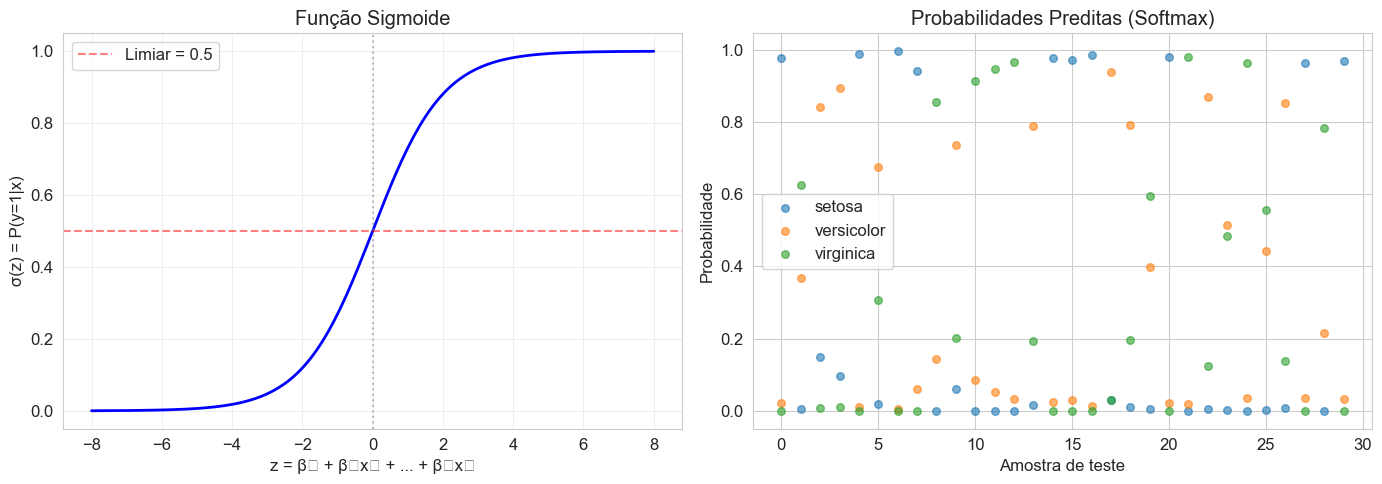

In [84]:
# Treinar Regressão Logística
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_iris_train_scaled, y_iris_train)

# Predições
y_iris_pred = log_reg.predict(X_iris_test_scaled)
y_iris_proba = log_reg.predict_proba(X_iris_test_scaled)

print("=" * 60)
print("  REGRESSÃO LOGÍSTICA — Dataset Iris")
print("=" * 60)
print(f"  Acurácia no teste: {accuracy_score(y_iris_test, y_iris_pred):.4f}")
print(f"  Nº de classes: {len(iris.target_names)}")
print(f"  Estratégia: multinomial (softmax) — padrão no scikit-learn")
print("=" * 60)

# Coeficientes por classe
print("\n📋 Coeficientes por classe:")
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=iris.feature_names,
    index=iris.target_names
)
print(coef_df.round(3).to_string())
print(f"\nInterceptos: {dict(zip(iris.target_names, log_reg.intercept_.round(3)))}")

# Visualização da função sigmoide
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoide
z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))
axes[0].plot(z, sigma, 'b-', linewidth=2)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Limiar = 0.5')
axes[0].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('z = β₀ + β₁x₁ + ... + βₚxₚ')
axes[0].set_ylabel('σ(z) = P(y=1|x)')
axes[0].set_title('Função Sigmoide')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Probabilidades preditas para as amostras de teste
for k, name in enumerate(iris.target_names):
    axes[1].scatter(range(len(y_iris_test)), y_iris_proba[:, k],
                    label=name, alpha=0.6, s=30)
axes[1].set_xlabel('Amostra de teste')
axes[1].set_ylabel('Probabilidade')
axes[1].set_title('Probabilidades Preditas (Softmax)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Avaliação do Modelo de Classificação

### Métricas de classificação:

| Métrica | Fórmula | Interpretação |
|---------|---------|---------------|
| **Acurácia** | $\frac{VP + VN}{Total}$ | Proporção de acertos gerais |
| **Precisão** | $\frac{VP}{VP + FP}$ | Dos classificados como positivos, quantos realmente são |
| **Recall** | $\frac{VP}{VP + FN}$ | Dos positivos reais, quantos foram detectados |
| **F1-Score** | $2 \cdot \frac{Precisão \cdot Recall}{Precisão + Recall}$ | Média harmônica entre precisão e recall |

  AVALIAÇÃO — Regressão Logística (Iris)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



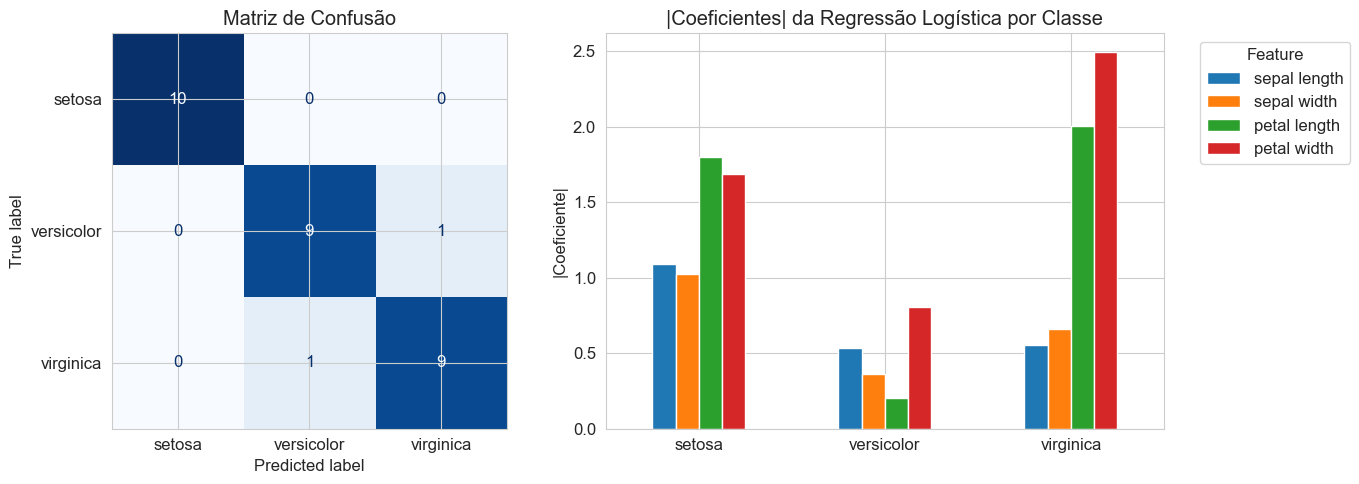

In [85]:
# Relatório de classificação
print("=" * 60)
print("  AVALIAÇÃO — Regressão Logística (Iris)")
print("=" * 60)
print(classification_report(y_iris_test, y_iris_pred, target_names=iris.target_names))

# Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap da matriz de confusão
cm = confusion_matrix(y_iris_test, y_iris_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão')

# Coeficientes da Regressão Logística por classe
coef_abs = pd.DataFrame(
    np.abs(log_reg.coef_),
    columns=[f.replace(' (cm)', '') for f in iris.feature_names],
    index=iris.target_names
)
coef_abs.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('|Coeficientes| da Regressão Logística por Classe')
axes[1].set_ylabel('|Coeficiente|')
axes[1].legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 13. Regressão Linear com TensorFlow/Keras

Conforme a ementa, vamos implementar o **mesmo problema de regressão** usando **TensorFlow/Keras**. Isso demonstra que um modelo linear é equivalente a uma rede neural com:
- **1 camada Dense** com 1 neurônio
- **Sem função de ativação** (linear)
- **Função custo MSE** e otimizador **SGD** ou **Adam**

Modelo equivalente:

$$\hat{y} = W \cdot X + b$$

Onde $W$ são os pesos (equivalentes a $\boldsymbol{\beta}$) e $b$ é o bias (equivalente a $\beta_0$).

In [86]:
# ============================================================
# Regressão Linear com TensorFlow/Keras
# ============================================================

# Construir o modelo — equivalente a LinearRegression()
tf.random.set_seed(RANDOM_STATE)

modelo_tf = keras.Sequential([
    layers.Dense(1, input_shape=(X_cal_train_scaled.shape[1],), activation='linear',
                 name='camada_linear')
])

modelo_tf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

modelo_tf.summary()

# Treinar o modelo
print("\n🚀 Treinando o modelo TensorFlow...")
history = modelo_tf.fit(
    X_cal_train_scaled, y_cal_train,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[
        callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    ],
    verbose=0
)

print("✅ Treinamento concluído!")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camada_linear (Dense)           │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Treinando o modelo TensorFlow...
✅ Treinamento concluído!


  COMPARAÇÃO: scikit-learn vs TensorFlow/Keras
  Métrica      scikit-learn     TensorFlow
------------------------------------------
  R²                 0.5758         0.5801
  MSE                0.5559         0.5502
  MAE                0.5332         0.5353

📋 Coeficientes: scikit-learn vs TensorFlow:
  Feature            sklearn   TensorFlow
----------------------------------------
  MedInc              0.8544       0.8273
  HouseAge            0.1225       0.1164
  AveRooms           -0.2944      -0.2348
  AveBedrms           0.3393       0.2784
  Population         -0.0023       0.0150
  AveOccup           -0.0408      -0.0407
  Latitude           -0.8969      -0.9483
  Longitude          -0.8698      -0.9028
----------------------------------------
  Intercepto          2.0719       2.0713


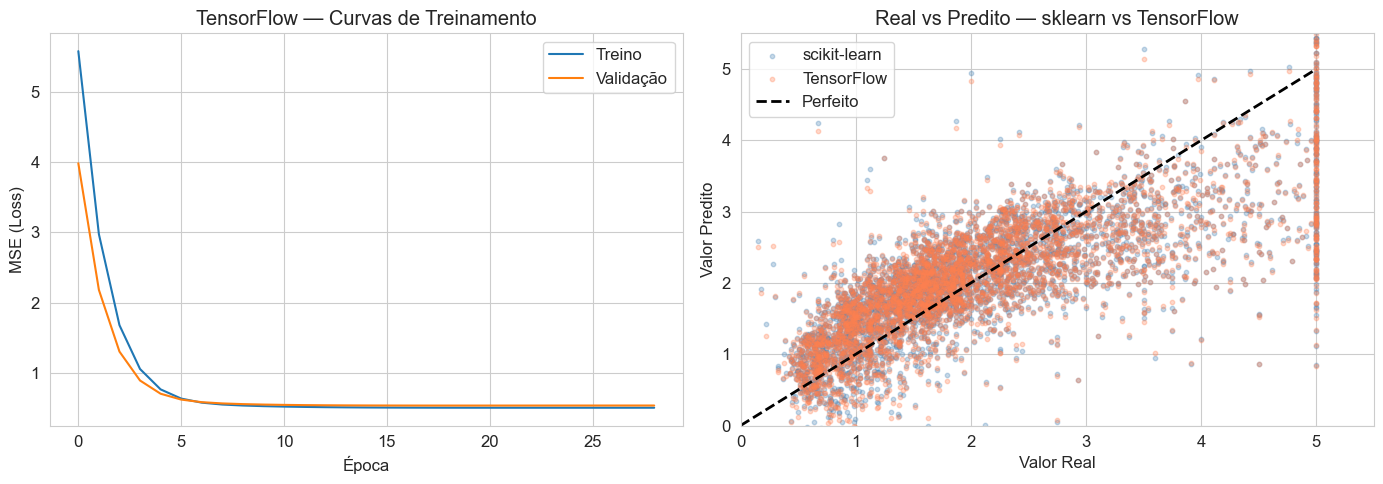


💡 Nota: ambos convergem para a mesma solução, pois são o mesmo modelo linear!
   A diferença está no método de otimização: OLS (sklearn) vs SGD/Adam (TensorFlow).


In [87]:
# Avaliar e comparar com scikit-learn
y_pred_tf = modelo_tf.predict(X_cal_test_scaled, verbose=0).flatten()

r2_tf = r2_score(y_cal_test, y_pred_tf)
mse_tf = mean_squared_error(y_cal_test, y_pred_tf)
mae_tf = mean_absolute_error(y_cal_test, y_pred_tf)

print("=" * 60)
print("  COMPARAÇÃO: scikit-learn vs TensorFlow/Keras")
print("=" * 60)
print(f"  {'Métrica':<10} {'scikit-learn':>14} {'TensorFlow':>14}")
print("-" * 42)
print(f"  {'R²':<10} {r2_score(y_cal_test, y_pred_multi):>14.4f} {r2_tf:>14.4f}")
print(f"  {'MSE':<10} {mean_squared_error(y_cal_test, y_pred_multi):>14.4f} {mse_tf:>14.4f}")
print(f"  {'MAE':<10} {mean_absolute_error(y_cal_test, y_pred_multi):>14.4f} {mae_tf:>14.4f}")
print("=" * 60)

# Comparar coeficientes
pesos_tf = modelo_tf.get_layer('camada_linear').get_weights()
w_tf = pesos_tf[0].flatten()
b_tf = pesos_tf[1][0]

print("\n📋 Coeficientes: scikit-learn vs TensorFlow:")
print(f"  {'Feature':<15} {'sklearn':>10} {'TensorFlow':>12}")
print("-" * 40)
for feat, c_sk, c_tf in zip(california.feature_names, lr_multi.coef_, w_tf):
    print(f"  {feat:<15} {c_sk:>10.4f} {c_tf:>12.4f}")
print("-" * 40)
print(f"  {'Intercepto':<15} {lr_multi.intercept_:>10.4f} {b_tf:>12.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de treinamento
axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE (Loss)')
axes[0].set_title('TensorFlow — Curvas de Treinamento')
axes[0].legend()

# Predito vs Real — comparação lado a lado
axes[1].scatter(y_cal_test, y_pred_multi, alpha=0.3, s=10, color='steelblue', label='scikit-learn')
axes[1].scatter(y_cal_test, y_pred_tf, alpha=0.3, s=10, color='coral', label='TensorFlow')
axes[1].plot([0, 5], [0, 5], 'k--', linewidth=2, label='Perfeito')
axes[1].set_xlabel('Valor Real')
axes[1].set_ylabel('Valor Predito')
axes[1].set_title('Real vs Predito — sklearn vs TensorFlow')
axes[1].legend()
axes[1].set_xlim(0, 5.5)
axes[1].set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

print("\n💡 Nota: ambos convergem para a mesma solução, pois são o mesmo modelo linear!")
print("   A diferença está no método de otimização: OLS (sklearn) vs SGD/Adam (TensorFlow).")

## 14. Visualização Comparativa dos Coeficientes

Vamos comparar visualmente os coeficientes de **todos os modelos de regressão** treinados. Isso permite entender o efeito da regularização na magnitude dos coeficientes.

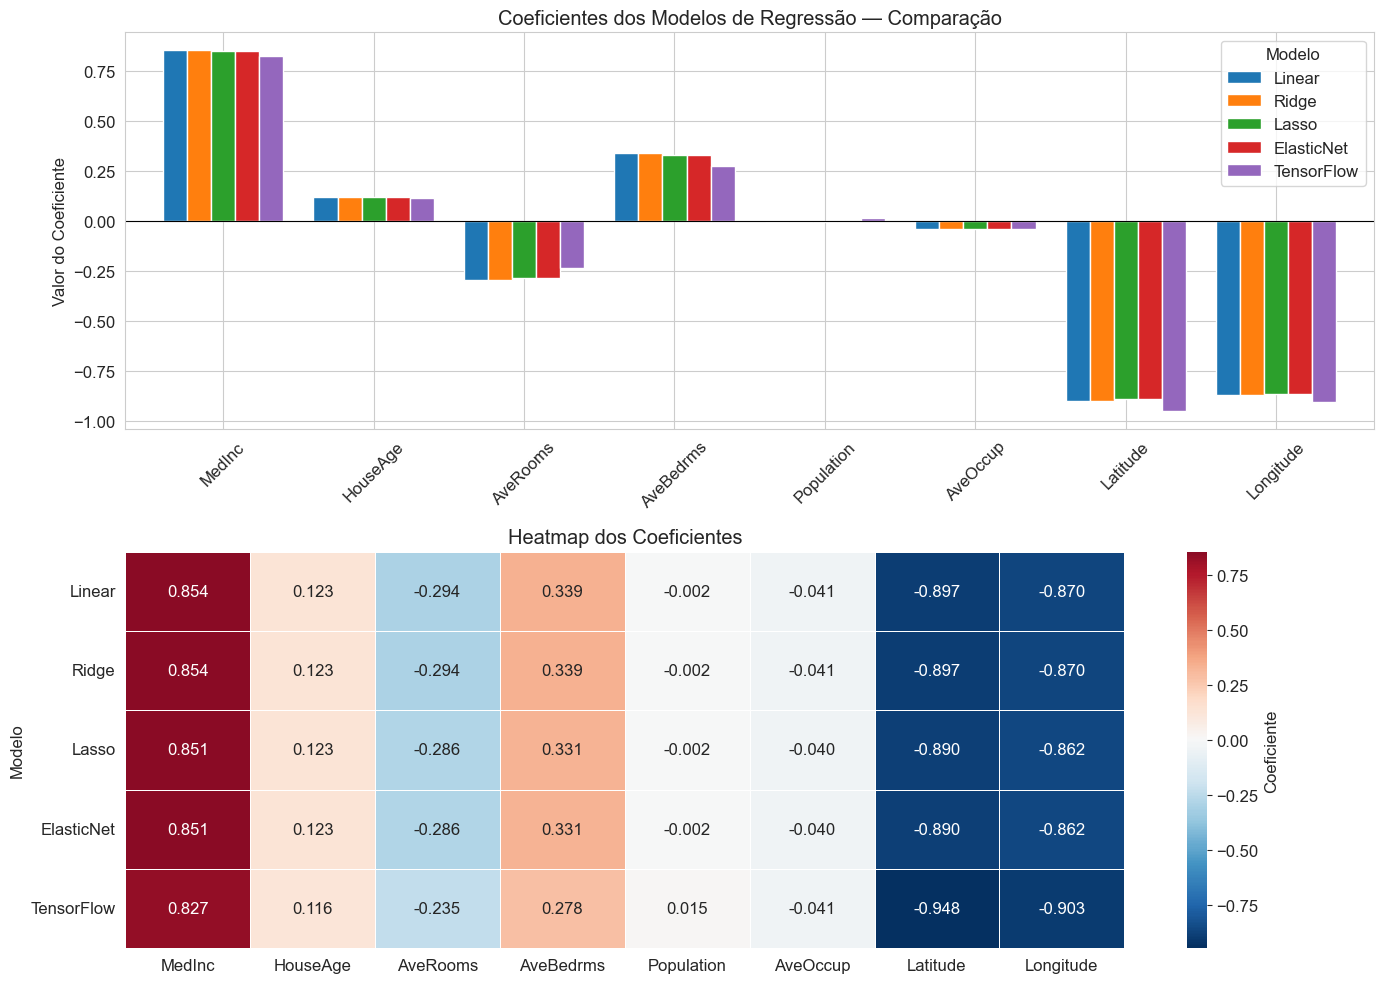


🔍 Interpretação:
  • Linear e TensorFlow produzem coeficientes muito semelhantes (mesmo modelo)
  • Ridge encolhe os coeficientes uniformemente (shrinkage)
  • Lasso pode zerar coeficientes (seleção de variáveis)
  • ElasticNet é um meio-termo entre Ridge e Lasso


In [88]:
# Comparação dos coeficientes de todos os modelos de regressão
coefs_compare = pd.DataFrame({
    'Linear': lr_multi.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_,
    'ElasticNet': enet_cv.coef_,
    'TensorFlow': w_tf,
}, index=california.feature_names)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico de barras agrupadas
coefs_compare.plot(kind='bar', ax=axes[0], rot=45, width=0.8)
axes[0].set_title('Coeficientes dos Modelos de Regressão — Comparação')
axes[0].set_ylabel('Valor do Coeficiente')
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].legend(title='Modelo')

# Heatmap
sns.heatmap(coefs_compare.T, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Coeficiente'})
axes[1].set_title('Heatmap dos Coeficientes')
axes[1].set_ylabel('Modelo')

plt.tight_layout()
plt.show()

print("\n🔍 Interpretação:")
print("  • Linear e TensorFlow produzem coeficientes muito semelhantes (mesmo modelo)")
print("  • Ridge encolhe os coeficientes uniformemente (shrinkage)")
print("  • Lasso pode zerar coeficientes (seleção de variáveis)")
print("  • ElasticNet é um meio-termo entre Ridge e Lasso")

## 15. Comparação Final de Desempenho com Validação Cruzada

Para uma avaliação mais **robusta**, vamos usar **validação cruzada com 5 folds** (`cross_val_score`). Isso evita que a comparação dependa de uma única divisão treino/teste.

$$CV_{score} = \frac{1}{K}\sum_{k=1}^{K} Score_k$$

  VALIDAÇÃO CRUZADA (5 folds) — Modelos de Regressão
  Modelo            R² médio   ± Desvio     R² min     R² max
----------------------------------------------------------
  Linear              0.6115     0.0065     0.6002     0.6201
  Ridge               0.6115     0.0065     0.6002     0.6201
  Lasso               0.6115     0.0063     0.6004     0.6200
  ElasticNet          0.6115     0.0063     0.6004     0.6200


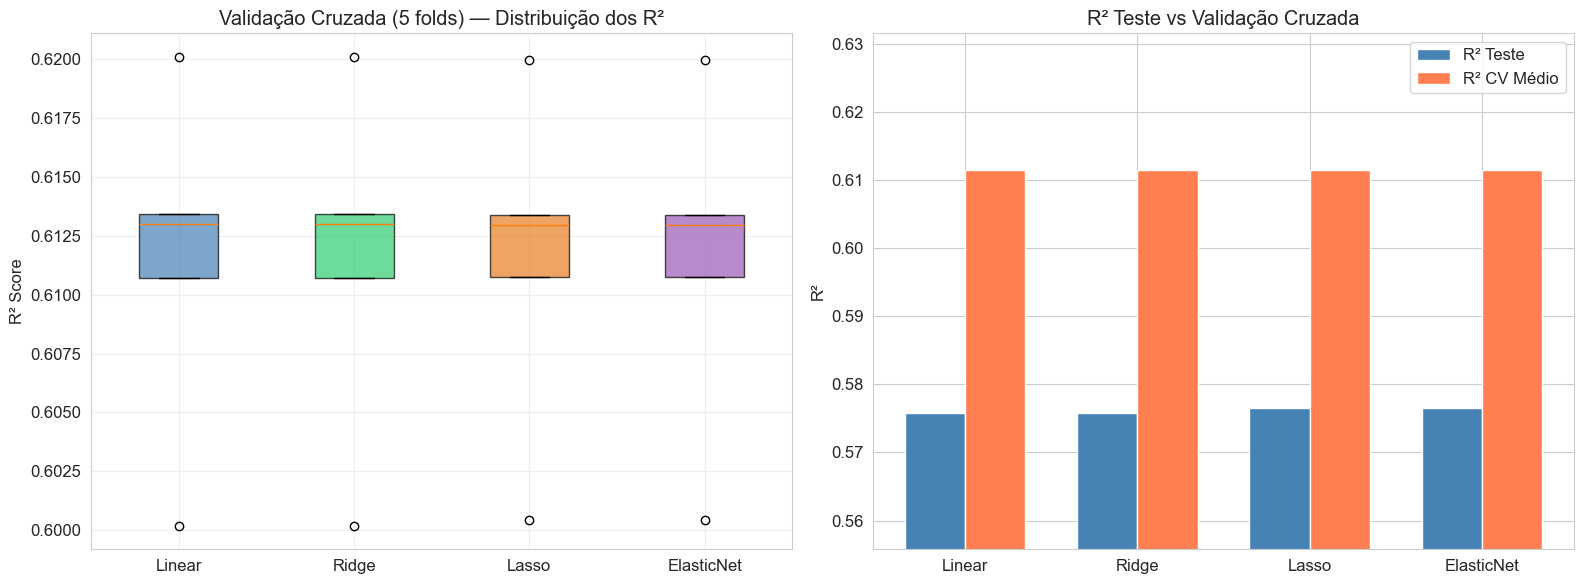


📊 Tabela Consolidada:


,R² (teste),R² CV (média),MSE (teste),MAE (teste)
Modelo,,,,
Linear,0.5758,0.6115,0.5559,0.5332
Ridge,0.5758,0.6115,0.5559,0.5332
Lasso,0.5765,0.6115,0.5550,0.5332
ElasticNet,0.5765,0.6115,0.5550,0.5332


In [89]:
# Validação Cruzada com 5 folds para todos os modelos de regressão
modelos_cv = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=ridge_cv.alpha_),
    'Lasso': Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000),
}

cv_results = {}
print("=" * 60)
print("  VALIDAÇÃO CRUZADA (5 folds) — Modelos de Regressão")
print("=" * 60)
print(f"  {'Modelo':<15} {'R² médio':>10} {'± Desvio':>10} {'R² min':>10} {'R² max':>10}")
print("-" * 58)

for nome, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_cal_train_scaled, y_cal_train,
                             cv=5, scoring='r2')
    cv_results[nome] = scores
    print(f"  {nome:<15} {scores.mean():>10.4f} {scores.std():>10.4f} "
          f"{scores.min():>10.4f} {scores.max():>10.4f}")

print("=" * 60)

# Boxplot dos scores de validação cruzada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
bp_data = [cv_results[m] for m in cv_results]
bp = axes[0].boxplot(bp_data, labels=cv_results.keys(), patch_artist=True)
colors_bp = ['steelblue', '#2ecc71', '#e67e22', '#9b59b6']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Validação Cruzada (5 folds) — Distribuição dos R²')
axes[0].grid(True, alpha=0.3)

# Tabela consolidada no conjunto de teste
df_final = pd.DataFrame({
    'Modelo': ['Linear', 'Ridge', 'Lasso', 'ElasticNet'],
    'R² (teste)': [r2_score(y_cal_test, y_pred_multi),
                   r2_score(y_cal_test, y_pred_ridge),
                   r2_score(y_cal_test, y_pred_lasso),
                   r2_score(y_cal_test, y_pred_enet)],
    'R² CV (média)': [cv_results[m].mean() for m in ['Linear', 'Ridge', 'Lasso', 'ElasticNet']],
    'MSE (teste)': [mean_squared_error(y_cal_test, p) for p in
                    [y_pred_multi, y_pred_ridge, y_pred_lasso, y_pred_enet]],
    'MAE (teste)': [mean_absolute_error(y_cal_test, p) for p in
                    [y_pred_multi, y_pred_ridge, y_pred_lasso, y_pred_enet]],
})

# Gráfico de barras agrupadas
x_pos = np.arange(len(df_final))
width = 0.35
axes[1].bar(x_pos - width/2, df_final['R² (teste)'], width, label='R² Teste', color='steelblue')
axes[1].bar(x_pos + width/2, df_final['R² CV (média)'], width, label='R² CV Médio', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_final['Modelo'])
axes[1].set_ylabel('R²')
axes[1].set_title('R² Teste vs Validação Cruzada')
axes[1].legend()
axes[1].set_ylim(df_final[['R² (teste)', 'R² CV (média)']].min().min() - 0.02, 
                 df_final[['R² (teste)', 'R² CV (média)']].max().max() + 0.02)

plt.tight_layout()
plt.show()

print("\n📊 Tabela Consolidada:")
df_final.set_index('Modelo').style.format('{:.4f}').highlight_max(
    axis=0, subset=['R² (teste)', 'R² CV (média)']
).highlight_min(axis=0, subset=['MSE (teste)', 'MAE (teste)'])

## 📝 Conclusão

Nesta aula cobrimos todos os pontos da ementa:

### ✅ Construção e Interpretação de Modelos Lineares
- **Regressão Linear Simples**: relação entre uma variável e o alvo — $\hat{y} = \beta_0 + \beta_1 x$
- **Regressão Linear Múltipla**: extensão para $p$ variáveis — $\hat{y} = X\boldsymbol{\beta}$
- **Regressão Logística**: classificação multiclasse via softmax — $P(y=k|x) = \frac{e^{z_k}}{\sum e^{z_j}}$
- Interpretação dos coeficientes em todos os modelos

### ✅ Aplicação com scikit-learn e TensorFlow
- **scikit-learn**: utilizado em todos os modelos (Linear, Ridge, Lasso, ElasticNet, Logística)
- **TensorFlow/Keras**: implementação equivalente da regressão linear como rede neural de 1 camada
- Demonstramos que ambas as bibliotecas convergem para a mesma solução

### ✅ Técnicas de Regularização
| Técnica | Penalidade | Efeito Principal |
|---------|-----------|------------------|
| **Ridge** | $\alpha\sum\beta_j^2$ | Shrinkage (encolhe coeficientes) |
| **Lasso** | $\alpha\sum|\beta_j|$ | Sparsity (zera coeficientes) |
| **ElasticNet** | $\alpha(\rho L_1 + (1-\rho)L_2)$ | Combina ambos os efeitos |

### ✅ Seleção de Variáveis
- **Lasso** como método embutido de seleção (coeficientes zerados = features eliminadas)
- **RFE** (Recursive Feature Elimination) como método wrapper
- **SelectFromModel** para seleção baseada em importância dos coeficientes

### 🔑 Pontos-chave para lembrar
1. **Regularização** previne overfitting ao penalizar coeficientes grandes
2. **Seleção de variáveis** melhora a interpretabilidade e pode melhorar a generalização
3. **Validação cruzada** é essencial para uma avaliação robusta dos modelos
4. Modelos lineares são a **base** de muitos algoritmos mais complexos em ML